# So sánh mô hình NER (PhoBERT vs XLM-RoBERTa) trên tập dữ liệu PhoNER_COVID19

Chào mừng đến với notebook phân tích và so sánh mô hình Nhận dạng Thực thể Có tên (Named Entity Recognition - NER). Trong dự án này, chúng ta sẽ giải quyết bài toán trích xuất thông tin từ các văn bản liên quan đến dịch bệnh COVID-19 bằng tiếng Việt.

### 🎯 Mục tiêu của Notebook
Notebook này được thiết kế để cung cấp một quy trình hoàn chỉnh (End-to-End) từ khâu khám phá dữ liệu, huấn luyện, cho đến đánh giá chuyên sâu. Chúng ta sẽ đặt lên bàn cân hai mô hình ngôn ngữ lớn phổ biến:
- **PhoBERT-base-v2**: Mô hình ngôn ngữ đặc tả cho tiếng Việt, nổi tiếng với khả năng hiểu ngữ nghĩa tiếng Việt xuất sắc.
- **XLM-RoBERTa-base**: Mô hình đa ngữ (Multilingual), được huấn luyện trên 100 ngôn ngữ khác nhau (bao gồm tiếng Việt), có kiến trúc từ vựng lớn.

### 🧠 Phương pháp tiếp cận (LoRA + CRF)
Để tối ưu hóa tài nguyên phần cứng nhưng vẫn đạt hiệu năng cao, chúng ta áp dụng:
1. **LoRA (Low-Rank Adaptation)**: Kỹ thuật Fine-tuning hiệu quả, chỉ cập nhật một lượng rất nhỏ trọng số thay vì toàn bộ mô hình hàng trăm triệu tham số.
2. **CRF (Conditional Random Fields)**: Lớp phân loại ở cuối giúp mô hình học được các quy luật ràng buộc chuỗi (ví dụ: nhãn `I-SYMPTOM` phải luôn đi sau `B-SYMPTOM` hoặc `I-SYMPTOM`).

In [2]:
!pip install -q transformers datasets peft pytorch-crf seqeval tensorboard accelerate

## 1. Import thư viện và Cấu hình môi trường
Đầu tiên, chúng ta tải các thư viện cần thiết. 
- **PyTorch, Transformers, PEFT**: Xây dựng và huấn luyện mạng Neural.
- **Seaborn, Matplotlib**: Vẽ biểu đồ phân tích trực quan.
- **Seqeval**: Thư viện tiêu chuẩn để tính điểm F1 cho bài toán Sequence Labeling (NER).

In [3]:
import glob
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import torch
import torch.nn as nn
from datasets import Dataset, concatenate_datasets
from peft import LoraConfig, get_peft_model
from sklearn.metrics import confusion_matrix
from torch.optim import AdamW
from torch.utils.data import DataLoader
from torchcrf import CRF
from tqdm.autonotebook import tqdm
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from seqeval.metrics import classification_report, f1_score

try:
    BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
except NameError:
    BASE_DIR = os.getcwd()

SRC_DIR = os.path.join(BASE_DIR, "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from augment import augment_entity_swap
from dataloader import load_phoner_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
FIG_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


## 2. Siêu tham số (Hyperparameters)
Việc thiết lập các siêu tham số đúng đắn quyết định rất lớn đến sự thành công của mô hình. Dưới đây là ý nghĩa của chúng:

### Tham số Huấn luyện
- `EPOCHS = 10`: Số lần mô hình nhìn thấy toàn bộ tập dữ liệu. Số vòng lặp đủ lớn để hội tụ nhưng cần cẩn thận overfitting.
- `BATCH_SIZE = 16`: Kích thước lô dữ liệu đưa vào mô hình mỗi lần. Tối ưu cho VRAM 15GB (như Kaggle T4).
- `MAX_LENGTH = 128`: Cắt/Bù (Padding/Truncation) câu về đúng độ dài này. Chúng ta sẽ xem biểu đồ EDA để thấy 128 là lựa chọn bao phủ hầu hết các câu.
- `WARMUP_RATIO = 0.1`: 10% số bước đầu tiên Learning Rate sẽ tăng từ từ lên mức Max, giúp mô hình ổn định trong giai đoạn đầu.

### Tham số LoRA
- `LORA_R = 16`: Rank của ma trận xấp xỉ. Càng lớn mô hình càng học được nhiều đặc trưng phức tạp nhưng tốn tài nguyên hơn.
- `LORA_ALPHA = 32`: Hệ số scale cho trọng số LoRA.
- `DROPOUT = 0.1`: Tỷ lệ ngẫu nhiên tắt các nơ-ron để chống Overfitting.

### Augmentation (Tăng cường dữ liệu)
Dữ liệu NER thường xuyên bị mất cân bằng trầm trọng. Ta sẽ giải quyết bằng cách sinh thêm các câu chứa thực thể hiếm gặp.
- `AUGMENT = True`: Bật tính năng tăng cường dữ liệu.
- `AUGMENT_TARGET = "JOB"`: Tập trung sinh thêm câu có chứa thực thể Nghề nghiệp (Job) - vốn là lớp dữ liệu ít nhất.
- `AUGMENT_N = 3`: Tạo ra 3 câu mới từ mỗi câu có chứa nhãn `JOB`.

In [4]:
EPOCHS = 10
BATCH_SIZE = 16
MAX_LENGTH = 128

# LoRA Config chung
LORA_R = 16
LORA_ALPHA = 32
DROPOUT = 0.1
WARMUP_RATIO = 0.1

# Augmentation
AUGMENT = True
AUGMENT_TARGET = "JOB"
AUGMENT_N = 3

DATA_DIR = os.path.join(BASE_DIR, "PhoNER_COVID19-main", "data", "word")
KAGGLE_INPUT_DIR = "/kaggle/input"

if os.path.exists(KAGGLE_INPUT_DIR):
    found_files = glob.glob(f"{KAGGLE_INPUT_DIR}/**/train_word.conll", recursive=True)
    if found_files:
        DATA_DIR = os.path.dirname(found_files[0])
    else:
        DATA_DIR = os.path.join(BASE_DIR, "PhoNER_COVID19-main", "data", "word")

print(f"Data dir: {DATA_DIR}")

Data dir: /kaggle/input/datasets/snvminh/testnlan/PhoNER_COVID19-main/data/word


## 3. Tiền xử lý dữ liệu
Tải dữ liệu từ các file định dạng CoNLL (mỗi dòng 1 từ và nhãn). Sau đó, nếu `AUGMENT=True`, dữ liệu tập Train sẽ được nối thêm các câu sinh tự động nhằm bù đắp cho sự thiếu hụt của các lớp thiểu số.

In [5]:
train_dataset, dev_dataset, test_dataset = load_phoner_dataset(DATA_DIR)

if AUGMENT:
    aug_tokens, aug_tags = augment_entity_swap(
        train_dataset, target_label=AUGMENT_TARGET, num_augments_per_sentence=AUGMENT_N
    )
    aug_dataset = Dataset.from_dict({"tokens": aug_tokens, "ner_tags": aug_tags})
    train_dataset = concatenate_datasets([train_dataset, aug_dataset])

unique_labels = set(tag for tags in train_dataset["ner_tags"] for tag in tags)
label_list = sorted(list(unique_labels))
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for i, label in enumerate(label_list)}
o_label_id = label2id.get("O", 0)

print(f"Train size: {len(train_dataset)}")
print(f"Nhãn: {label_list}")

Train size: 5615
Nhãn: ['B-AGE', 'B-DATE', 'B-GENDER', 'B-JOB', 'B-LOCATION', 'B-NAME', 'B-ORGANIZATION', 'B-PATIENT_ID', 'B-SYMPTOM_AND_DISEASE', 'B-TRANSPORTATION', 'I-AGE', 'I-DATE', 'I-JOB', 'I-LOCATION', 'I-NAME', 'I-ORGANIZATION', 'I-PATIENT_ID', 'I-SYMPTOM_AND_DISEASE', 'I-TRANSPORTATION', 'O']


## 4. Khám phá dữ liệu (Exploratory Data Analysis - EDA)
Trước khi đưa vào mô hình, ta cần "nhìn ngắm" dữ liệu:
- **Biểu đồ thứ 1**: Thể hiện hầu hết các câu dài bao nhiêu token. Điều này minh chứng cho việc chọn `MAX_LENGTH = 128` là hợp lý, giữ được đại đa số thông tin mà không gây lãng phí bộ nhớ.
- **Biểu đồ thứ 2**: Thể hiện sự mất cân bằng dữ liệu cực đoan. Nhãn `LOCATION` và `DATE` chiếm đa số, trong khi `JOB` (Nghề nghiệp) lại rất ít. Đây là rào cản lớn nhất của bài toán này.

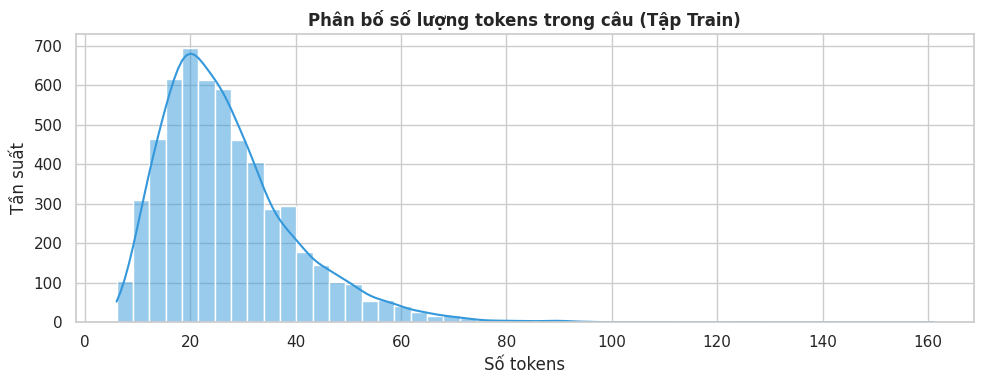

/tmp/ipykernel_350/796314901.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tags, x='Nhãn', y='Số lượng', palette="viridis")


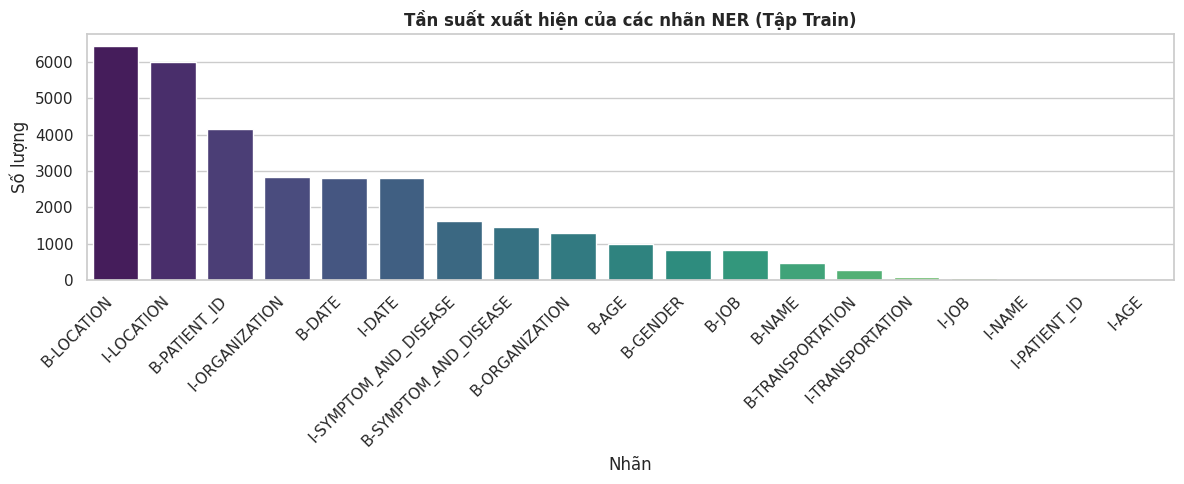

In [6]:
# 1. Phân bố chiều dài câu
seq_lengths = [len(tokens) for tokens in train_dataset["tokens"]]
plt.figure(figsize=(10, 4))
sns.histplot(seq_lengths, bins=50, kde=True, color="#3498db")
plt.title("Phân bố số lượng tokens trong câu (Tập Train)", fontweight="bold")
plt.xlabel("Số tokens")
plt.ylabel("Tần suất")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "seq_len_dist.png"))
plt.show()

# 2. Phân bố số lượng thực thể (Bỏ nhãn 'O')
all_tags = [tag for tags in train_dataset["ner_tags"] for tag in tags if tag != "O"]
tag_counts = Counter(all_tags)
df_tags = pd.DataFrame.from_dict(tag_counts, orient='index', columns=['Count']).sort_values(by='Count', ascending=False).reset_index()
df_tags.columns = ['Nhãn', 'Số lượng']

plt.figure(figsize=(12, 5))
sns.barplot(data=df_tags, x='Nhãn', y='Số lượng', palette="viridis")
plt.title("Tần suất xuất hiện của các nhãn NER (Tập Train)", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "tag_distribution.png"))
plt.show()

## 5. Kiến trúc Mô hình (Model Architecture)
Chúng ta định nghĩa Class cơ sở `BaseLoRACRF`:
- `self.backbone`: Là mô hình Transformer (PhoBERT/XLM-R) đã được bọc một lớp áo LoRA.
- `self.classifier`: Một lớp Fully Connected Layer để map các Embedding Vector về không gian của các nhãn (NER tags).
- `self.crf`: Lớp **Conditional Random Field**. Nó tính toán ma trận xác suất chuyển đổi (Transition Matrix) giữa các nhãn, phạt nặng những chuỗi nhãn vô lý (ví dụ nhảy thẳng từ nhãn `O` sang `I-LOCATION` mà không qua `B-LOCATION`).

In [7]:
class BaseLoRACRF(nn.Module):
    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = self.dropout(outputs.last_hidden_state)
        emissions = self.classifier(sequence_output)
        mask = attention_mask.bool()

        if labels is not None:
            clean_labels = labels.clone()
            clean_labels[clean_labels == -100] = self.pad_label_id
            log_likelihood = self.crf(emissions, clean_labels, mask=mask, reduction="token_mean")
            return -log_likelihood
        else:
            return self.crf.decode(emissions, mask=mask)

class PhoBertLoRACRF(BaseLoRACRF):
    def __init__(self, model_name, num_labels, pad_label_id=0):
        super().__init__()
        base_phobert = AutoModel.from_pretrained(model_name)
        peft_config = LoraConfig(r=LORA_R, lora_alpha=LORA_ALPHA, target_modules=["query", "key", "value", "dense"], bias="none")
        self.backbone = get_peft_model(base_phobert, peft_config)
        self.dropout = nn.Dropout(DROPOUT)
        self.classifier = nn.Linear(base_phobert.config.hidden_size, num_labels)
        self.crf = CRF(num_tags=num_labels, batch_first=True)
        self.pad_label_id = pad_label_id

class XLMRLoRACRF(BaseLoRACRF):
    def __init__(self, model_name, num_labels, pad_label_id=0):
        super().__init__()
        base_xlmr = AutoModel.from_pretrained(model_name)
        peft_config = LoraConfig(r=LORA_R, lora_alpha=LORA_ALPHA, target_modules=["query", "value"], bias="none")
        self.backbone = get_peft_model(base_xlmr, peft_config)
        self.dropout = nn.Dropout(DROPOUT)
        self.classifier = nn.Linear(base_xlmr.config.hidden_size, num_labels)
        self.crf = CRF(num_tags=num_labels, batch_first=True)
        self.pad_label_id = pad_label_id

## 6. Pipeline Huấn luyện và Đánh giá chính
Hàm `train_and_evaluate` xử lý toàn bộ quy trình cho một mô hình truyền vào:

**1. Tokenization phức tạp**:
Khi dùng các mô hình Sub-word tokenization (như BPE, WordPiece), 1 từ gốc có thể bị chẻ làm nhiều tokens. Ta phải gióng hàng (Align labels) sao cho token đầu tiên mang nhãn thực (VD: `B-LOC`), còn các token đuôi sẽ mang nhãn `-100` (để bỏ qua khi tính Loss). 
- `PhoBERT` yêu cầu cách align thủ công vì cơ chế phân tách từ của nó (dùng khoảng trắng / dấu gạch dưới).
- `XLM-R` có thể tận dụng tham số `is_split_into_words=True` của HuggingFace một cách tự động.

**2. Vòng lặp Huấn luyện (Training Loop)**:
Tối ưu bằng **AdamW**. Cơ chế Early Stopping sẽ giữ lại trạng thái (State Dict) có điểm số Validation F1 tốt nhất (Best Model) để làm phiên bản cuối cùng đem ra dự đoán.

**3. Đánh giá (Evaluation)**:
Báo cáo chi tiết trên tập Test thông qua hàm `classification_report` của thư viện Seqeval.

In [8]:
def train_and_evaluate(model_name_or_path, model_type):
    print(f"\n{'='*50}")
    print(f"BẮT ĐẦU HUẤN LUYỆN VÀ ĐÁNH GIÁ: {model_type}")
    print(f"{'='*50}\n")
    
    tokenizer = AutoTokenizer.from_pretrained(model_name_or_path)

    def align_phobert(examples):
        input_ids_batch, attention_mask_batch, labels_batch = [], [], []
        for words, tags in zip(examples["tokens"], examples["ner_tags"]):
            subword_ids = [tokenizer.bos_token_id if tokenizer.bos_token_id is not None else 0]
            subword_labels = [-100]
            for word, tag in zip(words, tags):
                word_subwords = tokenizer.encode(word, add_special_tokens=False)
                if not word_subwords: continue
                subword_ids.extend(word_subwords)
                subword_labels.append(label2id[tag])
                subword_labels.extend([-100] * (len(word_subwords) - 1))
            subword_ids.append(tokenizer.eos_token_id if tokenizer.eos_token_id is not None else 2)
            subword_labels.append(-100)
            if len(subword_ids) > MAX_LENGTH:
                subword_ids = subword_ids[:MAX_LENGTH]
                subword_labels = subword_labels[:MAX_LENGTH]
            padding_len = MAX_LENGTH - len(subword_ids)
            if padding_len > 0:
                attention_mask = [1] * len(subword_ids) + [0] * padding_len
                subword_ids = subword_ids + [tokenizer.pad_token_id] * padding_len
                subword_labels = subword_labels + [-100] * padding_len
            else:
                attention_mask = [1] * len(subword_ids)
            input_ids_batch.append(subword_ids)
            attention_mask_batch.append(attention_mask)
            labels_batch.append(subword_labels)
        return {"input_ids": input_ids_batch, "attention_mask": attention_mask_batch, "labels": labels_batch}

    def align_xlmr(examples):
        tokenized = tokenizer(examples["tokens"], is_split_into_words=True, padding="max_length", truncation=True, max_length=MAX_LENGTH)
        all_labels = []
        for i, ner_tags in enumerate(examples["ner_tags"]):
            word_ids = tokenized.word_ids(batch_index=i)
            previous_word_idx = None
            label_ids = []
            for word_idx in word_ids:
                if word_idx is None:
                    label_ids.append(-100)
                elif word_idx != previous_word_idx:
                    label_ids.append(label2id[ner_tags[word_idx]])
                else:
                    label_ids.append(-100)
                previous_word_idx = word_idx
            all_labels.append(label_ids)
        tokenized["labels"] = all_labels
        return tokenized

    align_func = align_phobert if model_type == "PhoBERT" else align_xlmr

    train_enc = train_dataset.map(align_func, batched=True)
    dev_enc = dev_dataset.map(align_func, batched=True)
    test_enc = test_dataset.map(align_func, batched=True)

    train_enc.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    dev_enc.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    test_enc.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

    train_loader = DataLoader(train_enc, batch_size=BATCH_SIZE, shuffle=True)
    dev_loader = DataLoader(dev_enc, batch_size=BATCH_SIZE)
    test_loader = DataLoader(test_enc, batch_size=BATCH_SIZE)

    if model_type == "PhoBERT":
        model = PhoBertLoRACRF(model_name_or_path, len(label_list), o_label_id).to(device)
        lr_lora = 3e-4
    else:
        model = XLMRLoRACRF(model_name_or_path, len(label_list), o_label_id).to(device)
        lr_lora = 1e-4

    optimizer_grouped_parameters = [
        {"params": [p for n, p in model.backbone.named_parameters() if p.requires_grad], "lr": lr_lora, "weight_decay": 0.01},
        {"params": model.classifier.parameters(), "lr": 1e-3 if model_type=="PhoBERT" else 5e-4, "weight_decay": 0.01},
        {"params": model.crf.parameters(), "lr": 2e-3 if model_type=="PhoBERT" else 1e-3, "weight_decay": 0.0},
    ]
    optimizer = AdamW(optimizer_grouped_parameters)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(total_steps * WARMUP_RATIO), num_training_steps=total_steps)

    best_f1 = 0.0
    best_model_state = None
    history = {"train_loss": [], "val_loss": [], "val_f1": []}
    
    for epoch in range(EPOCHS):
        model.train()
        total_train_loss = 0
        for batch in tqdm(train_loader, desc=f"[{model_type}] Epoch {epoch+1}/{EPOCHS}", leave=False):
            optimizer.zero_grad()
            loss = model(input_ids=batch["input_ids"].to(device), attention_mask=batch["attention_mask"].to(device), labels=batch["labels"].to(device))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            total_train_loss += loss.item()
        
        avg_train_loss = total_train_loss / len(train_loader)
        
        model.eval()
        val_preds, val_labels = [], []
        total_val_loss = 0
        with torch.no_grad():
            for batch in dev_loader:
                loss = model(input_ids=batch["input_ids"].to(device), attention_mask=batch["attention_mask"].to(device), labels=batch["labels"].to(device))
                total_val_loss += loss.item()
                
                preds = model(input_ids=batch["input_ids"].to(device), attention_mask=batch["attention_mask"].to(device))
                label_ids = batch["labels"].cpu().numpy()
                for i, label_seq in enumerate(label_ids):
                    valid_labels, valid_preds = [], []
                    for j, l in enumerate(label_seq):
                        if l != -100:
                            valid_labels.append(id2label[l])
                            valid_preds.append(id2label[preds[i][j]])
                    val_preds.append(valid_preds)
                    val_labels.append(valid_labels)
                    
        avg_val_loss = total_val_loss / len(dev_loader)
        val_f1 = f1_score(val_labels, val_preds)
        
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_f1"].append(val_f1)
        
        print(f"[{model_type}] Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val F1: {val_f1:.4f}")
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model_state = {k: v.cpu() for k, v in model.state_dict().items()}
            print(f"  --> New best model!")

    print(f"\n[{model_type}] Đánh giá trên tập test với model tốt nhất")
    model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    model.eval()
    test_preds, test_labels = [], []
    y_true_flat, y_pred_flat = [], []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Testing {model_type}"):
            preds = model(input_ids=batch["input_ids"].to(device), attention_mask=batch["attention_mask"].to(device))
            label_ids = batch["labels"].cpu().numpy()
            for i, label_seq in enumerate(label_ids):
                valid_labels, valid_preds = [], []
                for j, l in enumerate(label_seq):
                    if l != -100:
                        true_lbl = id2label[l]
                        pred_lbl = id2label[preds[i][j]]
                        valid_labels.append(true_lbl)
                        valid_preds.append(pred_lbl)
                        y_true_flat.append(true_lbl)
                        y_pred_flat.append(pred_lbl)
                test_preds.append(valid_preds)
                test_labels.append(valid_labels)

    report_str = classification_report(test_labels, test_preds)
    print(report_str)
    
    report_dict = {}
    report_dict["micro avg"] = {"f1-score": f1_score(test_labels, test_preds, average="micro")}
    report_dict["macro avg"] = {"f1-score": f1_score(test_labels, test_preds, average="macro")}
    report_dict["weighted avg"] = {"f1-score": f1_score(test_labels, test_preds, average="weighted")}
    
    for line in report_str.strip().split('\n')[2:]:
        parts = line.strip().split()
        if len(parts) >= 4 and parts[0] not in ["micro", "macro", "weighted", "avg", "avg/total"]:
            try:
                report_dict[parts[0]] = {"f1-score": float(parts[3])}
            except ValueError:
                pass
    
    return {
        "report": report_dict,
        "history": history,
        "y_true_flat": y_true_flat,
        "y_pred_flat": y_pred_flat
    }

## 7. Khởi chạy quá trình Huấn luyện
Chúng ta sẽ đưa 2 mô hình vào vòng lặp và ghi nhận mọi log/metrics sinh ra trong quá trình huấn luyện.

In [9]:
models_config = {
    "PhoBERT": "vinai/phobert-base-v2",
    "XLM-RoBERTa": "xlm-roberta-base"
}

results_dict = {}

for model_type, model_path in models_config.items():
    results_dict[model_type] = train_and_evaluate(model_path, model_type)



BẮT ĐẦU HUẤN LUYỆN VÀ ĐÁNH GIÁ: PhoBERT



Map:   0%|          | 0/5615 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

[XLM-RoBERTa] Epoch 9 | Train Loss: 0.0234 | Val Loss: 0.0332 | Val F1: 0.9231
  --> New best model!


[XLM-RoBERTa] Epoch 10/10:   0%|          | 0/351 [00:00<?, ?it/s]

[XLM-RoBERTa] Epoch 10 | Train Loss: 0.0221 | Val Loss: 0.0331 | Val F1: 0.9240
  --> New best model!

[XLM-RoBERTa] Đánh giá trên tập test với model tốt nhất


Testing XLM-RoBERTa:   0%|          | 0/188 [00:00<?, ?it/s]

                     precision    recall  f1-score   support

           LOCATION       0.91      0.93      0.92      4394
       ORGANIZATION       0.77      0.88      0.82       767
         PATIENT_ID       0.97      0.98      0.98      1951
               DATE       0.98      0.99      0.98      1641
             GENDER       0.87      0.98      0.92       447
                AGE       0.90      0.97      0.94       566
SYMPTOM_AND_DISEASE       0.81      0.85      0.83      1124
     TRANSPORTATION       0.96      0.95      0.96       193
               NAME       0.92      0.90      0.91       308
                JOB       0.39      0.53      0.45       173

          micro avg       0.90      0.93      0.92     11564
          macro avg       0.90      0.93      0.92     11564



## 8. Trực quan hóa và So sánh Hiệu năng
Phần này cung cấp hàng loạt biểu đồ phân tích kết quả dự đoán của cả 2 mô hình đặt cạnh nhau.

### 8.1 Đường cong học tập (Learning Curves)
Kiểm tra xem mô hình có bị Overfitting hay Underfitting không.
- **Loss Curve**: Loss trên tập Train giảm liên tục là tốt, nhưng nếu Loss trên tập Validation bất ngờ tăng mạnh, mô hình đang bị quá khớp (overfit).
- **F1 Curve**: Điểm F1 Validation tăng dần qua các Epoch chứng tỏ mô hình học tốt.

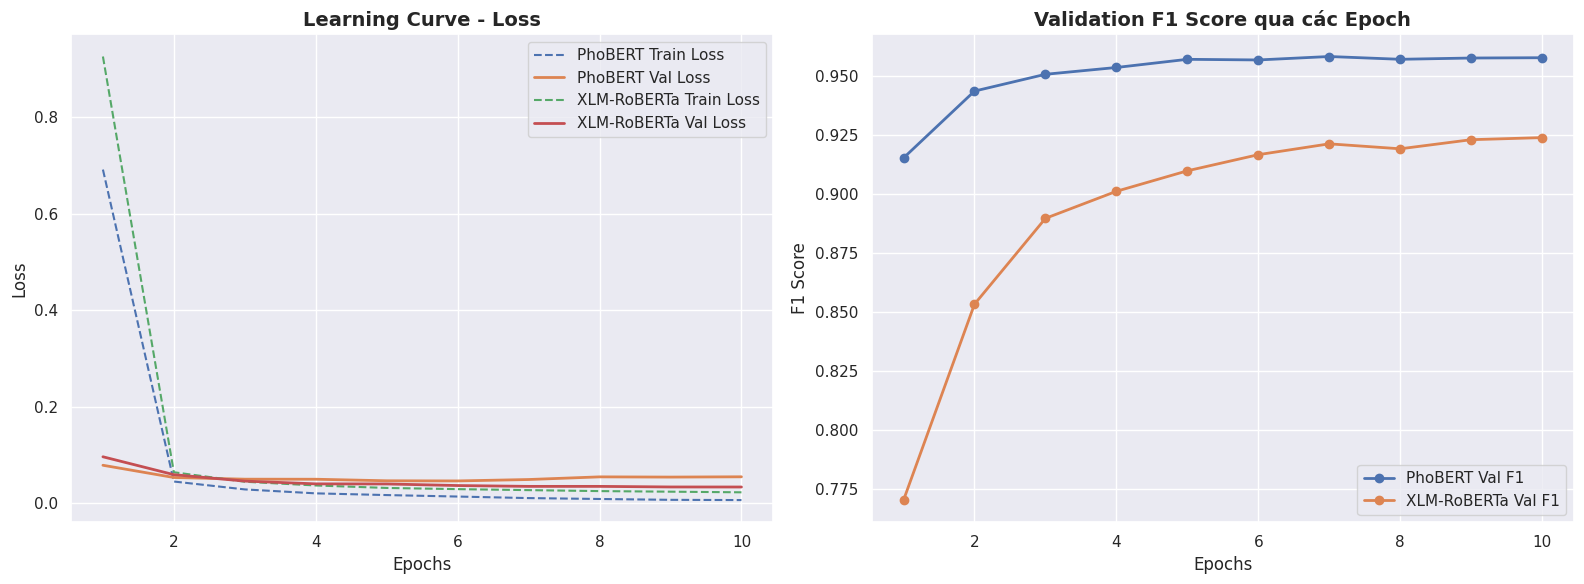

In [ ]:
sns.set_style("darkgrid")
models_list = list(results_dict.keys())
epochs = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ Loss
for m in models_list:
    axes[0].plot(epochs, results_dict[m]["history"]["train_loss"], linestyle='--', label=f'{m} Train Loss')
    axes[0].plot(epochs, results_dict[m]["history"]["val_loss"], linestyle='-', linewidth=2, label=f'{m} Val Loss')
axes[0].set_title('Learning Curve - Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Biểu đồ F1
for m in models_list:
    axes[1].plot(epochs, results_dict[m]["history"]["val_f1"], marker='o', linewidth=2, label=f'{m} Val F1')
axes[1].set_title('Validation F1 Score qua các Epoch', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('F1 Score')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "learning_curves.png"))
plt.show()

### 8.2 Ma trận Nhầm lẫn (Confusion Matrices)
Heatmap này trả lời câu hỏi: "Mô hình đang đoán nhầm lớp này thành lớp nào?". 
Các nhãn `B-` và `I-` được gộp chung thành tên thực thể gốc (như `LOCATION`, `SYMPTOM`) để biểu đồ dễ đọc hơn. Một mô hình hoàn hảo sẽ chỉ có màu đậm đà trên đường chéo (diagonal).

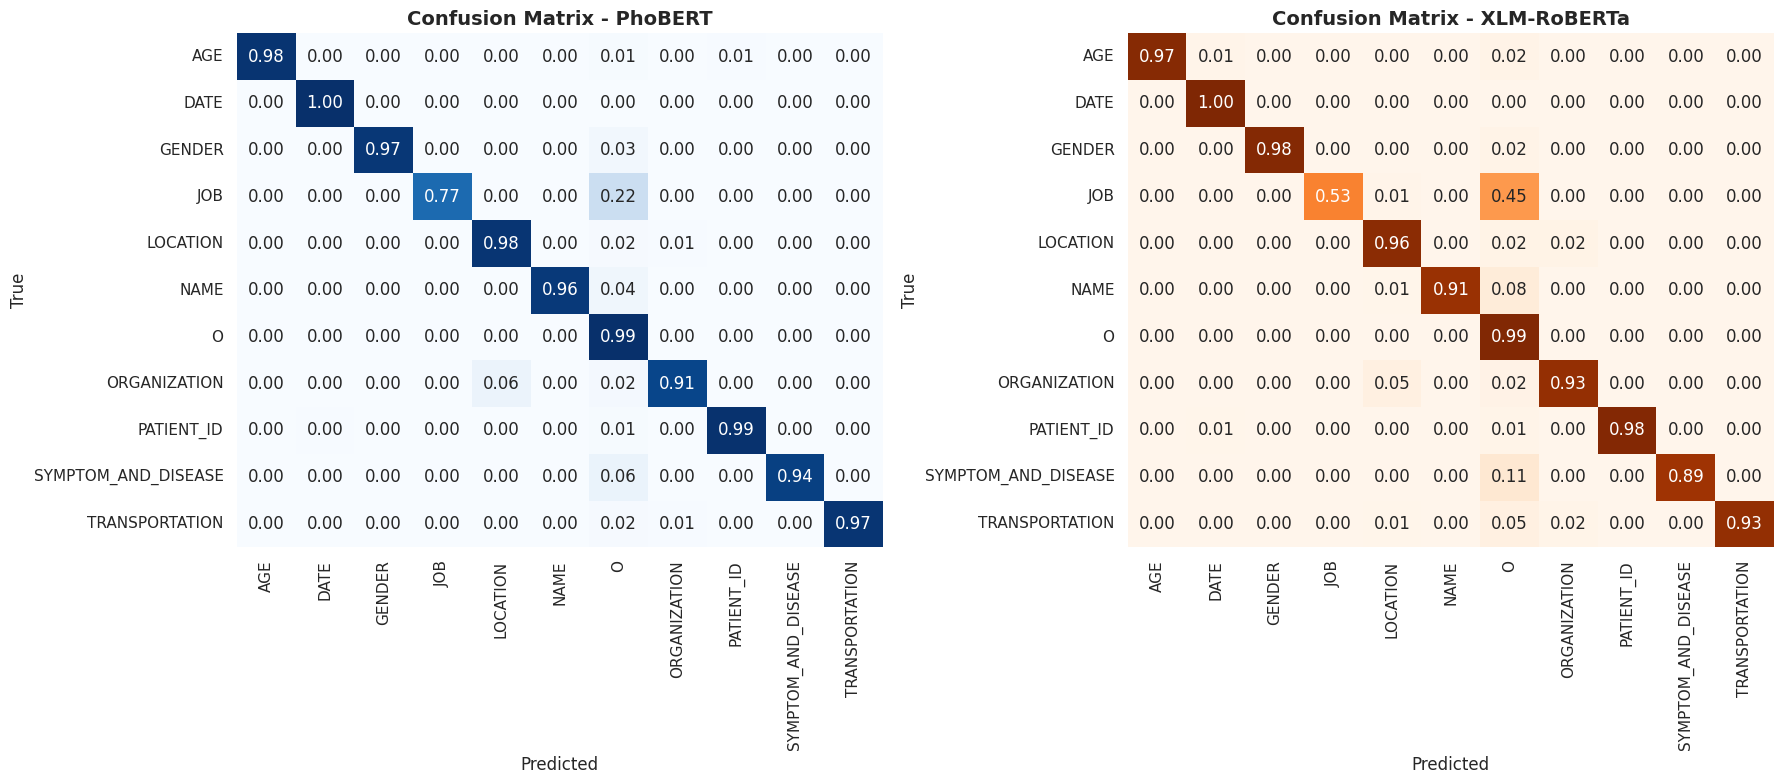

In [ ]:
def strip_prefix(label):
    return label[2:] if label.startswith("B-") or label.startswith("I-") else label

merged_label_list = sorted(list(set([strip_prefix(l) for l in label_list])))

fig, axes = plt.subplots(1, len(models_list), figsize=(18, 8))

for idx, m in enumerate(models_list):
    merged_y_true = [strip_prefix(l) for l in results_dict[m]["y_true_flat"]]
    merged_y_pred = [strip_prefix(l) for l in results_dict[m]["y_pred_flat"]]
    
    cm = confusion_matrix(merged_y_true, merged_y_pred, labels=merged_label_list)
    cm_norm = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)
    
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues" if idx==0 else "Oranges",
        xticklabels=merged_label_list, yticklabels=merged_label_list, ax=axes[idx], cbar=False
    )
    axes[idx].set_title(f'Confusion Matrix - {m}', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "confusion_matrices.png"))
plt.show()

### 8.3 So sánh F1 Tổng hợp
Bởi vì dữ liệu NER luôn mất cân bằng (nhãn `O` chiếm quá nhiều, `JOB` chiếm quá ít), dùng Accuracy (độ chính xác) là hoàn toàn sai lầm. Ta so sánh qua 3 góc nhìn:
- **Micro F1**: Coi tất cả các mẫu đều bình đẳng. Dễ bị chi phối bởi các lớp lớn (Major classes).
- **Macro F1**: Coi tất cả các nhóm (class) là bình đẳng. Lấy trung bình cộng F1 của tất cả các nhãn. Nếu dự đoán nhãn `JOB` quá tệ, Macro F1 sẽ rớt thảm hại. Đây là metric khắc nghiệt nhất.
- **Weighted F1**: Giống Macro F1 nhưng có nhân thêm trọng số lượng mẫu thực tế của class đó.

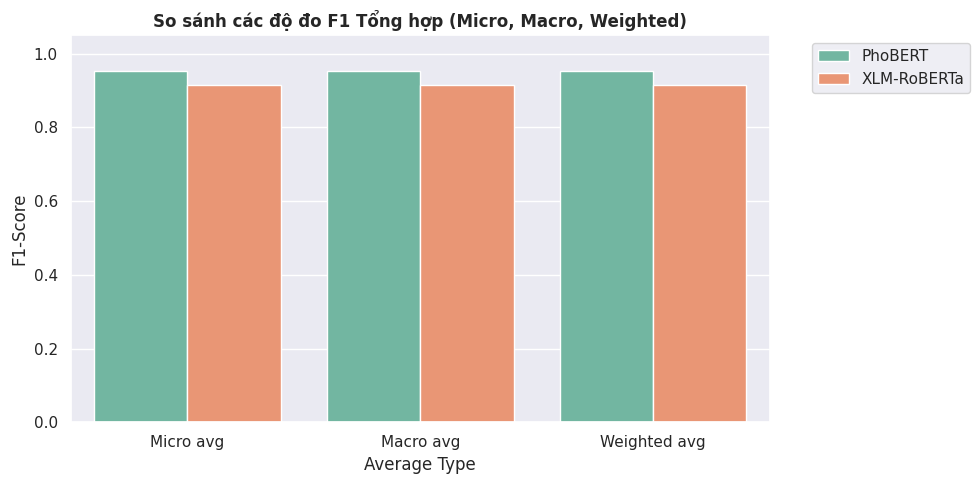

In [ ]:
overall_metrics = []
for m in models_list:
    report = results_dict[m]["report"]
    for avg_type in ["micro avg", "macro avg", "weighted avg"]:
        if avg_type in report:
            overall_metrics.append({
                "Model": m,
                "Average Type": avg_type.capitalize(),
                "F1-Score": report[avg_type]["f1-score"]
            })

df_overall = pd.DataFrame(overall_metrics)
plt.figure(figsize=(10, 5))
sns.barplot(data=df_overall, x="Average Type", y="F1-Score", hue="Model", palette="Set2")
plt.title("So sánh các độ đo F1 Tổng hợp (Micro, Macro, Weighted)", fontweight="bold")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "overall_metrics_comparison.png"))
plt.show()

### 8.4 Đánh giá chi tiết trên từng Nhãn thực thể
Cung cấp cái nhìn trực diện nhất: Mô hình nào nhận diện `SYMPTOM` tốt hơn? Mô hình nào bắt `PATIENT_ID` chính xác hơn? Biểu đồ barplot sẽ trực quan hóa rõ ràng câu trả lời.

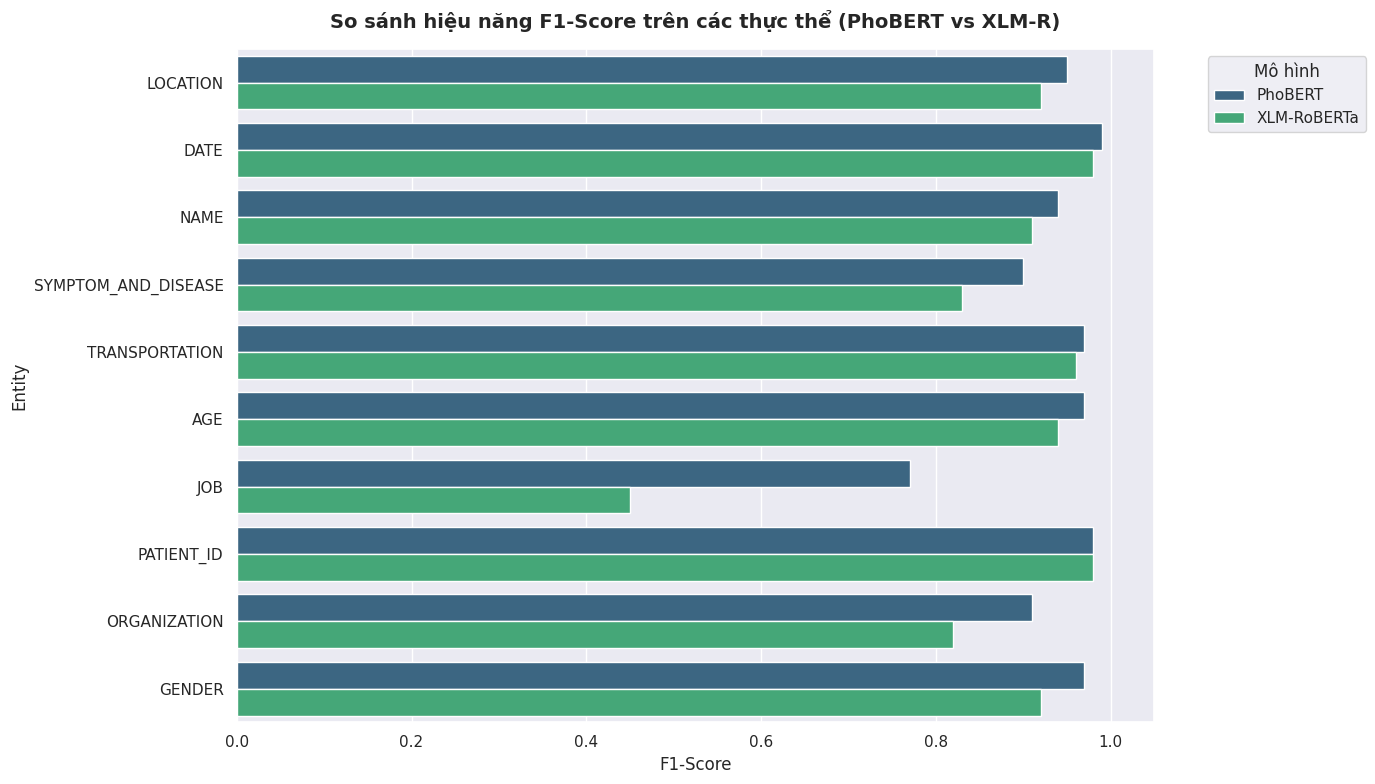

In [ ]:
f1_scores = []
for m in models_list:
    report = results_dict[m]["report"]
    for entity, metrics in report.items():
        if isinstance(metrics, dict) and entity not in ["micro avg", "macro avg", "weighted avg"]:
            f1_scores.append({
                "Model": m,
                "Entity": entity,
                "F1-Score": metrics["f1-score"]
            })

df_results = pd.DataFrame(f1_scores)

plt.figure(figsize=(14, 8))
sns.barplot(data=df_results, x="F1-Score", y="Entity", hue="Model", palette="viridis")

plt.title("So sánh hiệu năng F1-Score trên các thực thể (PhoBERT vs XLM-R)", fontsize=14, fontweight="bold", pad=15)
plt.xlim(0, 1.05)
plt.legend(title="Mô hình", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "model_comparison_f1.png"))
plt.show()